---
title: "Statistiques des risques extrêmes" 
sidebar: auto
author:
  name:
  - DEBA WANDJI Franck Delma
  - KOUGOUM MOKO MANI Marilene
date: "2025-03-24"
---


[Lien vers l'application Dash (GitHub)](https://github.com/usenameFD/STATISTIQUES-RISQUES-EXTREMES.git)
[Note de synthèse EVT](3A/rapports/projet_EVT.pdf)


## Recuperation des données et analyse des données

In [59]:
import functions
import importlib
import warnings
warnings.filterwarnings("ignore")


ticker_symbol = "^FCHI"
df_close = yf.download(ticker_symbol, start="2008-10-15", end = "2024-06-11")["Close"]
df_close.columns = ['Close']
df_close.head(2)

[*********************100%***********************]  1 of 1 completed


,Close
Date,
2008-10-15,3381.070068
2008-10-16,3181.000000


#### Exploration des données à notre disposition



Vérification des valeurs manquantes

In [60]:

missing_values = df_close.isnull().sum()
print(f"Nombre de valeurs manquantes dans la colonne 'Close': {missing_values[0]}")

Nombre de valeurs manquantes dans la colonne 'Close': 0


Résumé descriptif des données

In [61]:
summary = df_close['Close'].describe()
print("\nRésumé descriptif des prix de clôture :")
print(summary)


Résumé descriptif des prix de clôture :
count    4002.000000
mean     4909.823427
std      1289.022374
min      2519.290039
25%      3871.482483
50%      4755.440186
75%      5590.390015
max      8239.990234
Name: Close, dtype: float64


Calcul des log return

In [62]:
df_close['Log Return'] = np.log(df_close['Close'] / df_close['Close'].shift(1))
df_close = df_close.dropna()
df_close.head(2)

,Close,Log Return
Date,,
2008-10-16,3181.000000,-0.060997
2008-10-17,3329.919922,0.045753


Visualisation de l'évolution des prix de clôture ainsi que celle des log_return sur la période d'étude

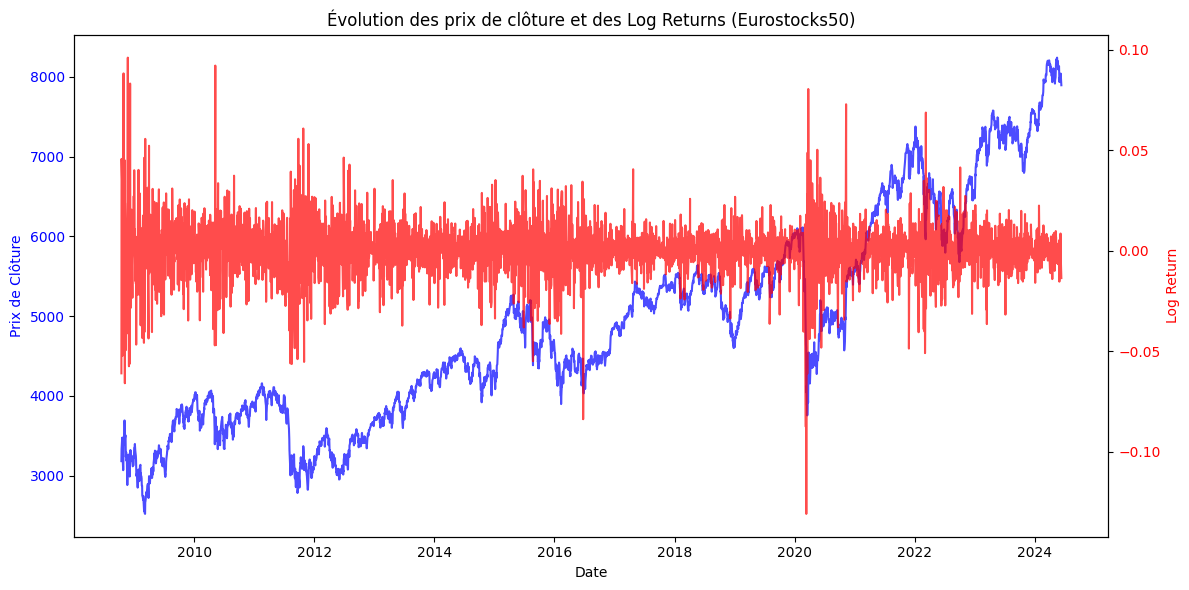

In [63]:
# Création du graphique
fig, ax1 = plt.subplots(figsize=(12, 6))

# Evolution de "Close" sur l'axe primaire
ax1.plot(df_close.index, df_close['Close'], color='blue', label='Close', alpha=0.7)
ax1.set_xlabel('Date')
ax1.set_ylabel('Prix de Clôture', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Création d'un deuxième axe y pour les log returns
ax2 = ax1.twinx()
ax2.plot(df_close.index, df_close['Log Return'], color='red', label='Log Return', alpha=0.7)
ax2.set_ylabel('Log Return', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Ajout des titres et légendes
plt.title("Évolution des prix de clôture et des Log Returns (Eurostocks50)")
fig.tight_layout()  
plt.show()


On observe dejà une tendance très marquée et haussiere au niveau des prix de clôture, signe que cette variable n'est pas stationnaire.

Les rendements en revanche semblent présenter une certaine regularité autour de la moyenne

Division de nos données en echantillon de train et de test

- Apprentissage : 15 octobre 2008 - 26 juillet 2022
- Test : 27 juillet 2022 - 11 juin 2024

In [72]:

train_start, train_end = "2008-10-15", "2022-07-26"  # la BCE a commencé à baisser ses taux directeurs
test_start, test_end = "2022-07-27", "2024-06-11"   # la BCE a commencé à relever progressivement ses taux directeurs


train_data = df_close.loc[train_start:train_end]
test_data = df_close.loc[test_start:test_end]

# Afficher les tailles des ensembles
print(f"Taille de l'ensemble d'entraînement: {train_data.shape[0]} jours")
print(f"Taille de l'ensemble de test: {test_data.shape[0]} jours")


Taille de l'ensemble d'entraînement: 3522 jours
Taille de l'ensemble de test: 479 jours


#### Statistiques descriptives sur les 2 jeux de données

Nous nous intéressons aux caractéristiques de tendance centrale et de dispersion usuelles et, du fait du constat fait sur le graphique de l'évolution des prix de cloture et des log-rendements sur la période d'étude, nous réalisons également des test de stationnarité à savoir : le test de Dick et Fuller augmenté et le test de KPSS.

##### Echantillon train

In [73]:
importlib.reload(functions)
resultat = functions.descriptive_statistics(train_data, train_data.columns)
resultat

,Statistic,Close,Log Return
0,Mean,4601.646103,0.000173
1,Median,4463.850098,0.000582
2,Variance,1044911.013882,0.000193
3,Standard Deviation,1022.20889,0.013904
4,Skewness,0.402481,-0.268165
5,Kurtosis,-0.483977,7.302393
6,ADF p-value,0.461665,0.0
7,KPSS p-value,0.01,0.1
8,ADF Stationarity,Non stationnaire,Stationnaire
9,KPSS Stationarity,Non stationnaire,Stationnaire


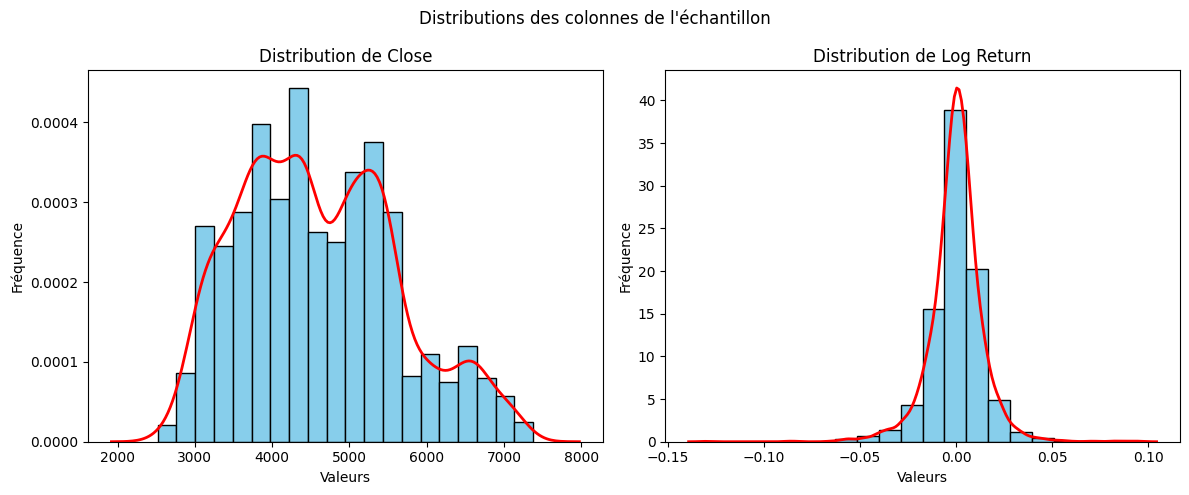

In [74]:
functions.plot_histograms(train_data, train_data.columns)

**Commentaire**


Sur l'échantillon de train, les prix sont non stationnaires, et assez variables, avec un écart-type de 1022 pour une moyenne de 4601, soit près de 1/4 de la valeur moyenne. 

Les log rendements en revanche présentent une certaine régularité autour de leur moyenne (0.000173) comme l'attestent les tests de stationnarité de Dick et Fuller augmenté et de KPSS. On note toute fois une asymétrie marquée (-0.26) et des queues lourdes (avec un excess kurtosis de 7.30) contrairement aux prix de clôture



##### Echantillon test

In [75]:
stat_test = functions.descriptive_statistics(test_data, test_data.columns)
stat_test

,Statistic,Close,Log Return
0,Mean,7178.986868,0.0005
1,Median,7260.72998,0.000767
2,Variance,346425.733475,0.000078
3,Standard Deviation,588.57942,0.008812
4,Skewness,-0.369065,-0.126194
5,Kurtosis,-0.2724,1.960086
6,ADF p-value,0.715622,0.0
7,KPSS p-value,0.01,0.1
8,ADF Stationarity,Non stationnaire,Stationnaire
9,KPSS Stationarity,Non stationnaire,Stationnaire


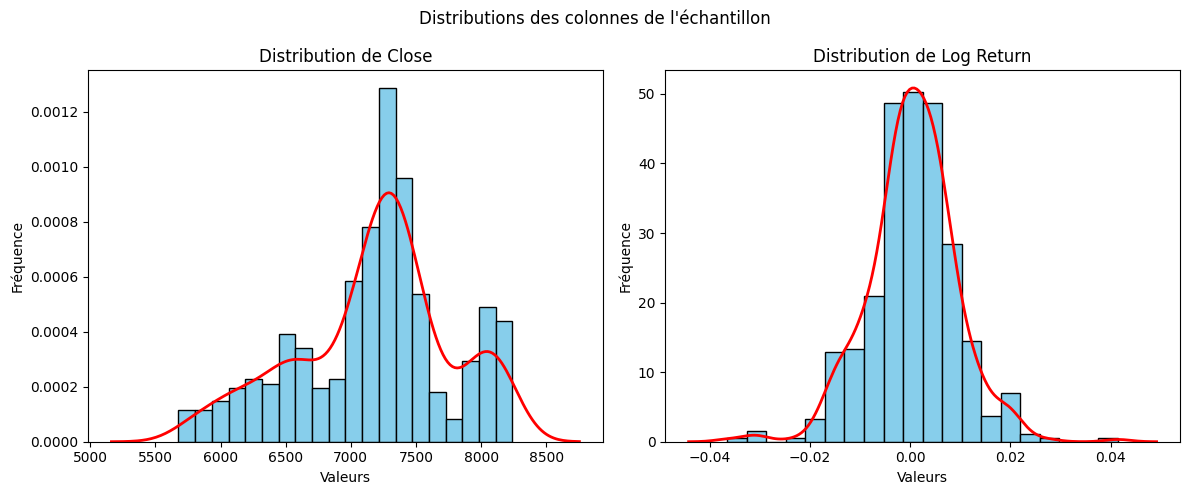

In [76]:
functions.plot_histograms(test_data, test_data.columns)

**Commentaire**

Les caractéristiques de stationnarité sont similaires entre l'échantillon de test et l'échantillon d'entraînement.

Cependant, l'échantillon de test présente en moyenne des prix et des rendements logarithmiques plus élevés, tout en étant moins dispersés.

En ce qui concerne les distributions des rendements logarithmiques, les queues de l'échantillon de test sont moins lourdes que celles de l'échantillon d'entraînement. Toutefois, elles restent plus épaisses que celles d'une loi normale, comme l'indique un excès de kurtosis de 1,96.

## 	VaR non paramétrique



### VaR Historique



Ecrire une fonction calculant la VaR historique d’un ensemble de log-rendements : VaR_Hist(x, alpha)

Calcul de la VaR historique à horizon 1 jour  sur base d’apprentissage pour alpha = 99%.

In [77]:
importlib.reload(functions)
var_99_hist = functions.VaR_Hist(train_data['Log Return'])
print(f"VaR historique à 99% sur un  horizon d'un jour : {var_99_hist:.4%}")

VaR historique à 99% sur un  horizon d'un jour : -4.0517%


### VaR Bootstrap



Ecrire une fonction calculant la VaR historique bootstrap d’un ensemble de log-rendements et donnant un IC de niveau alpha_IC de cette VaR


Nous choisissons de prendre la médiane des VaR des differents echantillons bootstrapés car elle est plus robuste que la moyenne.
Nous choississons un nombre d'itération suffisamment grand pour nous assurer de la pertinence de la VaR estimée. On choisit également N tel que Nα soit divisible par 2 afin de pouvoir extraire des indices exacts pour les quantiles d’ordre
Nα/2 et 1−Nα/2.


Calcul  de  la VaR historique bootstrap et l’IC associé à 90% sur base d’apprentissage pour alpha = 99%.


In [78]:
importlib.reload(functions)
var_bootstrap_99, var_ci = functions.VaR_Hist_Bootstrap(train_data['Log Return'],confidence_level=0.99, n_iterations=10000, ci_level=0.90)

# Affichage des résultats
print(f"VaR Bootstrap à 99% sur un jour : {var_bootstrap_99:.4%}")
print(f"Intervalle de confiance à 95% : [{var_ci[0]:.4%}, {var_ci[1]:.4%}]")


VaR Bootstrap à 99% sur un jour : -4.0517%
Intervalle de confiance à 95% : [-4.3588%, -3.8138%]



Calcul du nombre d’exceptions sur base de test associées à la VaR historique calculée précédemment



In [79]:
importlib.reload(functions)
functions.var_exceptions(test_data, var_99_hist)

Nombre d'exceptions (log-returns inférieurs à la VaR à 99%) : 0
Pourcentage d'exceptions : 0.00%



Comparer statistiquement ce pourcentage d’exceptions avec le niveau de risque attendu

Nous mettons ici en place le test statistique **d'unconditional coverage**.

### Test d'unconditionnal coverage : Présentation du principe 


**Présentation du principe du test d'unconditional coverage**




Le test d'**Unconditional Coverage** évalue si la proportion d'excès observés (c'est-à-dire les rendements inférieurs à la VaR) correspond à la probabilité théorique de dépassement, $\alpha$ (1% dans notre cas).

- **Hypothèse nulle (H₀)** : La proportion d'excès observée est égale à $\alpha$.
  
- **Statistique de test** : Le test est basé sur le rapport de vraisemblance (Likelihood Ratio, LR) :
  
  $$
  LR_{\text{uc}} = -2 \cdot \log\left( (1 - \alpha)^{n - n_{\text{excès}}} \cdot \alpha^{n_{\text{excès}}} \right) + 2 \cdot \log\left( (1 - \hat{p}_{\text{emp}})^{n - n_{\text{excès}}} \cdot \hat{p}_{\text{emp}}^{n_{\text{excès}}} \right)
  $$

  où :
  - $n$ est le nombre total d'observations,
  - $n_{\text{excès}}$ est le nombre d'excès (jours où le rendement est inférieur à la VaR),
  - $\hat{p}_{\text{emp}}$ est la proportion empirique d'excès observée.

- **p-value** : La statistique suit une loi du chi-deux à 1 degré de liberté. La p-value est obtenue comme suit :
  
  $$
  p_{\text{uc}} = 1 - \chi^2_{\text{cdf}}(LR_{\text{uc}}, df=1)
  $$

- **Conclusion** : Si $p_{\text{uc}} > \text{seuil de significativité}$ (nous avons choisi 0.05), on ne rejette pas l'hypothèse nulle et la proportion d'excès observée est cohérente avec la probabilité théorique $\alpha$. Sinon, on rejette l'hypothèse nulle.



**Resultat du test**

In [80]:
importlib.reload(functions)
LR_uc, p_value = functions.unconditional_coverage_test(test_data, var_99_hist, significance_level=0.01)

Nombre d'exceptions observées : 0
--------------------------------------------------
Nombre total d'observations : 479
--------------------------------------------------
Probabilité de dépassement empirique : 0.0000
--------------------------------------------------
Statistique LR pour le test d'unconditional coverage : 9.6282
--------------------------------------------------
P-value du test d'unconditional coverage : 0.0019
--------------------------------------------------
L'hypothèse nulle est rejetée : Le modèle de VaR ne couvre pas correctement les exceptions.


## VaR Gaussienne



#### Ecrire une fonction calculant la VaR gaussienne d’un ensemble de log-rendements


Calcul de la VaR gaussienne sur base d’apprentissage pour alpha = 99%.

In [81]:
importlib.reload(functions)

var_gauss = functions.VaR_Gauss(train_data, alpha=0.99)
print(f"VaR Gaussienne à 99% sur un jour : {var_gauss:.4%}")

VaR Gaussienne à 99% sur un jour : -3.2172%


#### Faire une validation ex-ante de cette VaR Gaussienne (analyses graphiques, QQ-plot, etc.)



**Comparaison de la courbe densité empirique des log return et de la courbe de densité théorique supposée**

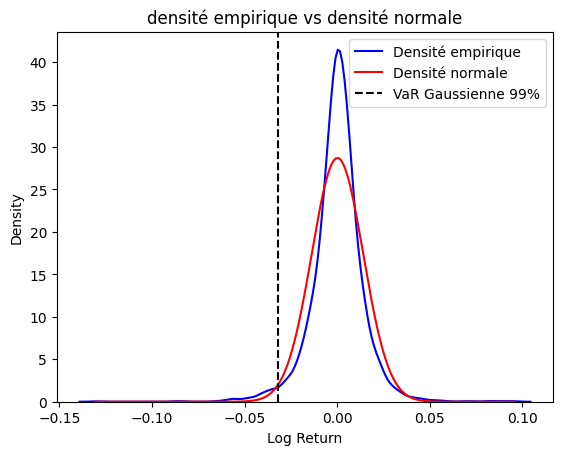

In [82]:
importlib.reload(functions)
functions.plot_kde_vs_gauss(train_data)

On observe que la distribution réelle est plus concentrée au centre et présente des queues plus épaisses que la loi normale supposée. Ceci indique une fréquence plus élevée d’événements extrêmes que ne le prévoit la loi normale. Ainsi, A priori, notre VaR gaussienne à 99% sous-estime le risque réel.

Nous utilisons un QQ-plot afin de conforter cette observation


**QQ-plot**

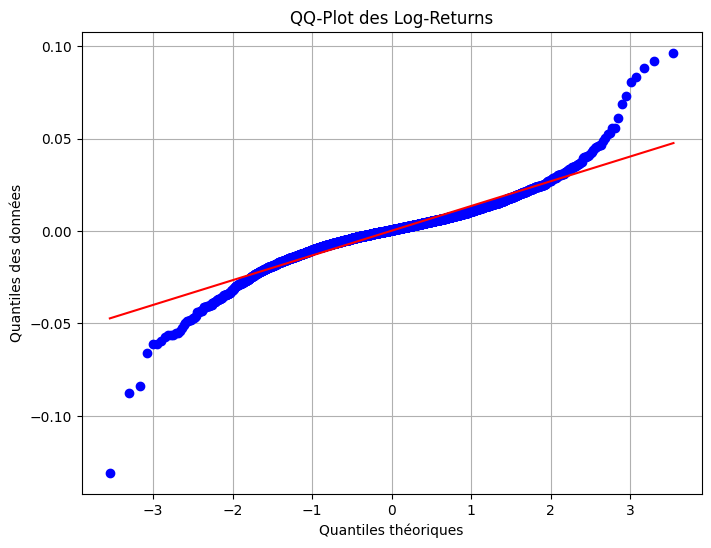

In [84]:
importlib.reload(functions)
functions.plot_qq(train_data['Log Return'])

Le QQ-plot compare les quantiles empiriques des log-returns à ceux d’une distribution normale. On observe que :

-   Au centre de la distribution, les points suivent approximativement la droite théorique, ce qui indique une légère conformité à la normalité.

-   Aux extrémités, les points s’écartent fortement de la droite, révélant des queues épaisses

Il semblerait donc bien que la loi normale ne soit pas celle adaptée à nos données. 

Nous confortons ces resultats visuels à l'aide de tests statistiques. Nous utilisons un test statistique d'adéquation (Kolmogorov-smirnov)

**Test de Kolmogorov Smirnov**

In [85]:
importlib.reload(functions)
functions.ks_test(train_data['Log Return'])

Statistique KS: 0.0803
P-valeur: 0.0000
Resultat du test : Rejet de l'hypothèse de normalité au seuil de 5% 


Le test d'adéquation corrobore les observations faites précédemment. On s'attend donc à ce que la Var ici calibrée ne passe pas le test d'unconditional coverage.

**Test d'unconditional coverage**

In [86]:
functions.unconditional_coverage_test(train_data, var_gauss, significance_level=0.01)

Nombre d'exceptions observées : 78
--------------------------------------------------
Nombre total d'observations : 3522
--------------------------------------------------
Probabilité de dépassement empirique : 0.0221
--------------------------------------------------
Statistique LR pour le test d'unconditional coverage : 39.0018
--------------------------------------------------
P-value du test d'unconditional coverage : 0.0000
--------------------------------------------------
L'hypothèse nulle est rejetée : Le modèle de VaR ne couvre pas correctement les exceptions.


(39.00181311712197, 4.234120831725363e-10)

Effectivemment , cette VaR ne couvre pas correctement les exceptions: **Elle sous-estime le risque de perte**

####  Calcul de  la VaR gaussienne à 10j par la méthode de scaling


La VaR gaussienne à 10 jours est estimée en multipliant la VaR quotidienne par la racine carrée du nombre de jours (10 jours dans ce cas)

$$
\text{VaR}_{10j} = \text{VaR}_{1j} \times \sqrt{10}
$$

où :
- $\text{VaR}_{1j}$ est la VaR calculée sur une période de 1 jour,
- $\sqrt{10}$ est le facteur de scaling basé sur le nombre de jours (10 jours ici).

In [87]:
importlib.reload(functions)
var_10j = functions.var_gauss_horizon(var_gauss, horizon=10)

VaR à 10 jours : -10.17%



#### Calcul de la VaR Gaussienne à 10 jours par la méthode de diffusion d'un actif


La VaR gaussienne à 10 jours peut être calculée en utilisant la méthode de diffusion d'un actif, basée sur le modèle suivant pour l'évolution du prix de l'actif :

$$
dS = S \cdot \mu \cdot dt + S \cdot \sigma \cdot Z \cdot \sqrt{dt}
$$

où :
- $Z \sim N(0, 1)$ (bruit blanc suivant une loi normale standard),
- $S_0$ est la valeur du cours de clôture de l'actif à la dernière date de l'échantillon d'apprentissage,
- $dt = 1 \, \text{jour}$,
- $\mu$ et $\sigma$ sont les paramètres estimés dans la section 2.b (moyenne et écart-type des rendements log-transformés).

Cette méthode permet d'estimer la VaR en tenant compte de la dynamique de diffusion du prix de l'actif.

---


La formule utilisée pour simuler les trajectoires du prix est obtenue en resolvant l'EDS présentée plus haut: 

$S_t = S_{t-1} \cdot \exp\left(\left(\mu - 0.5 \cdot \sigma^2\right) \cdot \Delta t + \sigma \cdot Z\right)$

Ici, $ \Delta t = 1 $ car la simulation est effectuée sur des étapes d'une unité de temps (1 jour).


In [88]:
importlib.reload(functions)

## Paramètres
S0 = float(train_data[['Close']].iloc[-1])
mu = np.mean(train_data['Log Return'])
sigma = np.std(train_data['Log Return'])
t = 10
num_simulations = 1000


St = functions.simulate_price_paths(t, S0, mu, sigma, num_simulations)
log_returns = functions.calculate_log_returns(St, S0)

# Calcul de la VaR  à 99%
var_99 = functions.calculate_var(log_returns)

VaR diffusée à 99.0% pour un horizon de 10 jours : -0.0996



#####  Aperçu de quelques trajectoires de prix


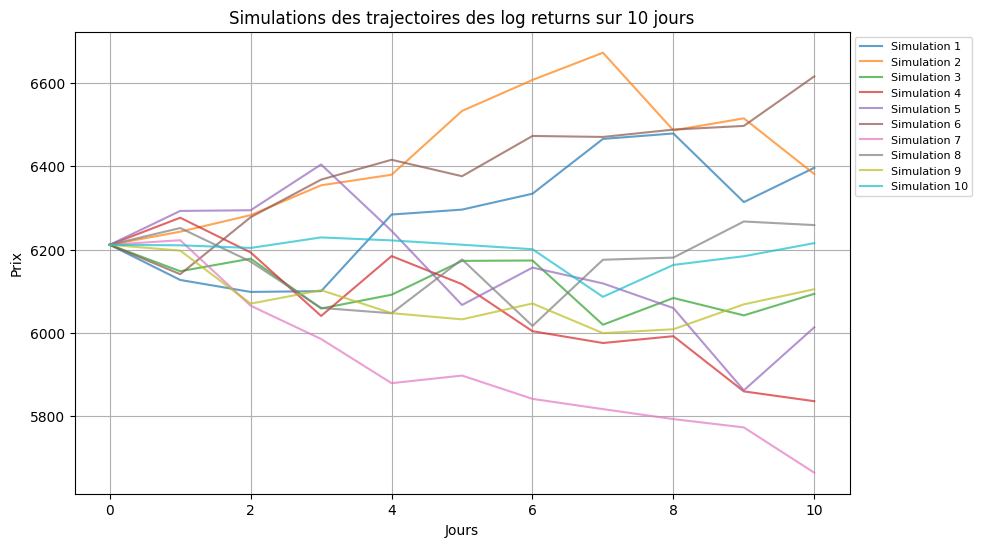

In [91]:
importlib.reload(functions)
num_trajectoires =10
functions.plot_simulations(St, num_trajectoires, t)

### Calcul de la VaR Gaussienne à 1 jour avec EWMA


La **VaR Gaussienne** à 1 jour est calculée en surpondérant les observations les plus récentes avec la méthode **EWMA** (Exponential Weighted Moving Average).

Les poids sont définis par :
- $ \omega_i (\lambda) = \lambda^i (1 - \lambda) $, où $ \lambda $ est le paramètre de lissage et $ i $ l'indice de l'observation.

Les poids normalisés sont :
- $ \tilde{\omega}_i (\lambda) = \frac{\omega_i (\lambda)}{\sum_{i=0}^{T} \omega_i (\lambda)} $.

La moyenne et la variance sont calculées comme suit :
- $ \hat{\mu}(\lambda) = \sum_{i=0}^{T} \tilde{\omega}_i (\lambda) r_{T-i} $,
- $ \hat{\sigma}^2 (\lambda) = \sum_{i=0}^{T} \tilde{\omega}_i (\lambda) (r_{T-i} - \hat{\mu} (\lambda))^2 $.

Cela permet de calculer la VaR en utilisant les rendements pondérés, avec une importance plus grande pour les rendements récents.




**Calcul de mu et sigma ewma pour differentes valeurs de lambda**

In [107]:
importlib.reload(functions)
lambdas = [ 0.9 , 0.95 , 0.99  ]
for lambda_ in lambdas:
    result = functions.calculate_mu_sigma_ewma(train_data['Log Return'], lambda_)

print("L'ecart-type non pondéré des log rendements dans l'echantillon train est : ", train_data['Log Return'].std())
print('-'*50)
print("La moyenne non pondérée des log rendements dans l'echantillon train est : ", train_data['Log Return'].mean())
print('-'*50)


Pour λ = 0.9:
  - μ̂(λ) = -0.0019
  - σ̂(λ) = 0.0409
----------------------------------------
Pour λ = 0.95:
  - μ̂(λ) = -0.0015
  - σ̂(λ) = 0.0380
----------------------------------------
Pour λ = 0.99:
  - μ̂(λ) = -0.0005
  - σ̂(λ) = 0.0273
----------------------------------------
L'ecart-type non pondéré des log rendements dans l'echantillon train est :  0.013903729926502252
--------------------------------------------------
La moyenne non pondérée des log rendements dans l'echantillon train est :  0.00017268658342823863
--------------------------------------------------


**Commentaire**



Plus λ est grand, plus on lisse, et plus on se concentre sur les données récentes.

Et des résultats précédents, en parcourant ces valeurs de λ, on observe que les log-rendements récents semblent moins négatifs et moins volatils lorsque lambda grandit, ce qui se reflète dans une moyenne μ̂ qui remonte légèrement (de -0.0019 à -0.0005) et une volatilité σ̂ qui diminue (de 0.0409 à 0.0273).

Cependant, ces écarts-types pondérés restent nettement supérieurs à l’écart-type non pondéré de l’échantillon (≈ 0.0139).

De plus, alors que la moyenne non pondérée est  positive (≈ 0.00017), les moyennes pondérées sont toutes négatives, ce qui indique une tendance à la perte dans les observations récentes .

On s’attend donc à une VaR plus sévère que celle issue d’une approche non pondérée, car les récentes performances sont à la fois plus volatiles et plus négatives. Cela dit, à mesure que λ augmente, la VaR devrait décroître, en cohérence avec une baisse de la volatilité estimée.


---

**Calcul de la VaR gaussienne selon la méthode EWMA**



Pour calculer la VaR gaussienne à 99% selon la méthode EWMA, on utilise les paramètres estimés $ \hat{\mu}(\lambda) $ et $ \hat{\sigma}^2(\lambda) $. La VaR est ensuite calculée à l'aide de la formule suivante :

$ \text{VaR}_{\text{EWMA}} = \hat{\mu}(\lambda) - \text{Quantile}_{1-\alpha} \times \hat{\sigma}(\lambda) $


In [108]:
importlib.reload(functions)
for lambda_ in lambdas:
    var_ewma = functions.calculate_var_gauss_ewma(train_data['Log Return'], lambda_, alpha=0.99)

Pour λ = 0.9:
  - μ̂(λ) = -0.0019
  - σ̂(λ) = 0.0409
----------------------------------------
VaR gaussienne EWMA à 1 jour (α = 99.0%): -0.0971
----------------------------------------
Pour λ = 0.95:
  - μ̂(λ) = -0.0015
  - σ̂(λ) = 0.0380
----------------------------------------
VaR gaussienne EWMA à 1 jour (α = 99.0%): -0.0898
----------------------------------------
Pour λ = 0.99:
  - μ̂(λ) = -0.0005
  - σ̂(λ) = 0.0273
----------------------------------------
VaR gaussienne EWMA à 1 jour (α = 99.0%): -0.0640
----------------------------------------


Les resultats observés corroborent bien notre analyse faite précédemment. Les pertes decroissent à mesure que lambda grandit. Mais, elles demeurent bien plus sévères  que celle observée sans pondération.


On constate par ailleurs que ces VaR pondérées sont toutes plus sévères que la VaR historique calculée précédemment, on s'attend donc à ce qu'il n'y ait pas d'exception et que le test d'unconditionnal coverage ne soit pas satisfait.

Pour s'en convaincre, exécutons le code qui calcule le nombre d'exception et fait le test.

In [111]:
### Pour lambda = 0.9

var_ewma = functions.calculate_var_gauss_ewma(train_data['Log Return'], 0.9, alpha=0.99)
LR_uc, p_value = functions.unconditional_coverage_test(test_data, var_ewma, significance_level=0.01)
print("-"*40)

Pour λ = 0.9:
  - μ̂(λ) = -0.0019
  - σ̂(λ) = 0.0409
----------------------------------------
VaR gaussienne EWMA à 1 jour (α = 99.0%): -0.0971
----------------------------------------
Nombre d'exceptions observées : 0
--------------------------------------------------
Nombre total d'observations : 479
--------------------------------------------------
Probabilité de dépassement empirique : 0.0000
--------------------------------------------------
Statistique LR pour le test d'unconditional coverage : 9.6282
--------------------------------------------------
P-value du test d'unconditional coverage : 0.0019
--------------------------------------------------
L'hypothèse nulle est rejetée : Le modèle de VaR ne couvre pas correctement les exceptions.
----------------------------------------


In [112]:
### Pour lambda = 0.95

var_ewma = functions.calculate_var_gauss_ewma(train_data['Log Return'], 0.95, alpha=0.99)
LR_uc, p_value = functions.unconditional_coverage_test(test_data, var_ewma, significance_level=0.01)
print("-"*40)

Pour λ = 0.95:
  - μ̂(λ) = -0.0015
  - σ̂(λ) = 0.0380
----------------------------------------
VaR gaussienne EWMA à 1 jour (α = 99.0%): -0.0898
----------------------------------------
Nombre d'exceptions observées : 0
--------------------------------------------------
Nombre total d'observations : 479
--------------------------------------------------
Probabilité de dépassement empirique : 0.0000
--------------------------------------------------
Statistique LR pour le test d'unconditional coverage : 9.6282
--------------------------------------------------
P-value du test d'unconditional coverage : 0.0019
--------------------------------------------------
L'hypothèse nulle est rejetée : Le modèle de VaR ne couvre pas correctement les exceptions.
----------------------------------------


In [113]:
### Pour lambda = 0.99

var_ewma = functions.calculate_var_gauss_ewma(train_data['Log Return'], 0.99, alpha=0.99)
LR_uc, p_value = functions.unconditional_coverage_test(test_data, var_ewma, significance_level=0.01)
print("-"*40)

Pour λ = 0.99:
  - μ̂(λ) = -0.0005
  - σ̂(λ) = 0.0273
----------------------------------------
VaR gaussienne EWMA à 1 jour (α = 99.0%): -0.0640
----------------------------------------
Nombre d'exceptions observées : 0
--------------------------------------------------
Nombre total d'observations : 479
--------------------------------------------------
Probabilité de dépassement empirique : 0.0000
--------------------------------------------------
Statistique LR pour le test d'unconditional coverage : 9.6282
--------------------------------------------------
P-value du test d'unconditional coverage : 0.0019
--------------------------------------------------
L'hypothèse nulle est rejetée : Le modèle de VaR ne couvre pas correctement les exceptions.
----------------------------------------



##### Que peut-on retenir à ce niveau?


La VaR gaussienne calculée sans pondération sous-estime le risque de perte. En effet, le taux de dépassement observé est de 2.21 %, bien supérieur au seuil théorique de 1 % attendu pour une VaR à 99 %. 

Pour y remédier, le recours à une VaR gaussienne avec pondération EWMA pourrait être pertinent, car elle permet d’accorder plus d’importance aux observations récentes. Toutefois, lorsqu’on choisit un λ trop élevé, on observe une VaR excessivement conservatrice. Dans ce cas, la mesure de risque devient trop sensible aux rendements récents, au point de perdre en représentativité globale.

**Conclusion** : Il est donc essentiel de trouver un λ adapté, capable d’assurer un bon compromis entre réactivité et stabilité. Un λ trop faible dilue l'information récente, tandis qu’un λ trop élevé amplifie les variations court terme. Le choix optimal de λ permettrait ainsi une évaluation plus réaliste et efficace du risque de perte.

## 	VaR skew-Student



Estimation des paramètres d'une loi de Skew Student par maximum de vraisemblance


Nous allons estimer les paramètres d'une loi de Skew Student en utilisant la méthode du maximum de vraisemblance. Nous procéderons par étapes :

- **Définition de la fonction de densité** 
- **Fonction de log-vraisemblance** 
- **Optimisation de la log-vraisemblance** 

*Rappel*

Soit $X$ une variable aléatoire suivant une loi Skew Student, avec les paramètres $\\mu$ (moyenne), $\\sigma$ (écart-type), $\\gamma$ (paramètre de skewness) et $\\nu$ (degrés de liberté).

La fonction de densité est donnée par la formule suivante :

$$
f_{\\{skew-student}}(x) = 2 \times f(x) \times F(x)
$$

où :

- $f(x)$ est la fonction de densité de la loi de Student avec $\\nu$ degrés de liberté,
- $F(x)$ est la fonction de répartition (CDF) de la loi de Student avec $\\nu + 1$ degrés de liberté.

---



### Estimation des paramètres de loi Skew Student sur base d’apprentissage.

In [123]:

importlib.reload(functions)
log_returns = train_data['Log Return'].values  

# Estimation des paramètres optimaux
params_optimaux = functions.optimize_parameters(log_returns)

if params_optimaux is not None:
    mu_opt, sigma_opt, gamma_opt, nu_opt = params_optimaux
    print(f"Paramètres estimés de la loi Skew Student :")
    print(f" - Moyenne (mu) : {mu_opt}")
    print(f" - Ecart-type (sigma) : {sigma_opt}")
    print(f" - Skewness (gamma) : {gamma_opt}")
    print(f" - Degrés de liberté (nu) : {nu_opt}")
else:
    print("L'optimisation a échoué.")


Paramètres estimés de la loi Skew Student :
 - Moyenne (mu) : 0.002291764183250922
 - Ecart-type (sigma) : 0.008826290591700056
 - Skewness (gamma) : -0.22702918460022958
 - Degrés de liberté (nu) : 2.980532470548153


####  Mise en place  d'une validation ex-ante de cet ajustement



**Comparaison des fonctions de densité**

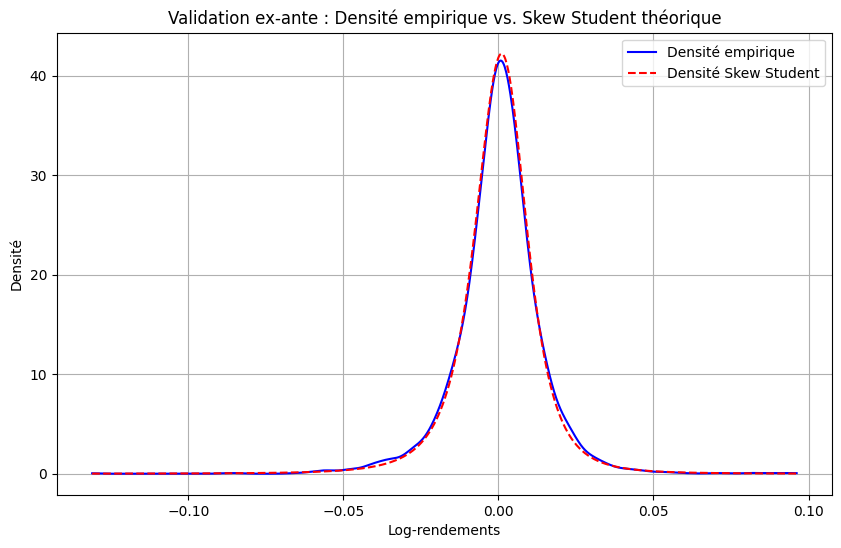

In [133]:
importlib.reload(functions)
functions.plot_skew_student_fit(log_returns, mu_opt, sigma_opt, gamma_opt, nu_opt, functions.f_skew_student)

La loi skew-student semble assez bien s'ajuster à nos données. On peut cependant noter que, au niveau des queues de distribution, la densité théorique est légèrement en dessous de la densité empirique. 

Mais, ici, la qualité de l'ajustement semble bien meilleure que celle avec la loi normale. 

On s'intéresse au QQ-plot.



**Evaluation de la qualité de l'ajustement aux données via des QQ-plot**

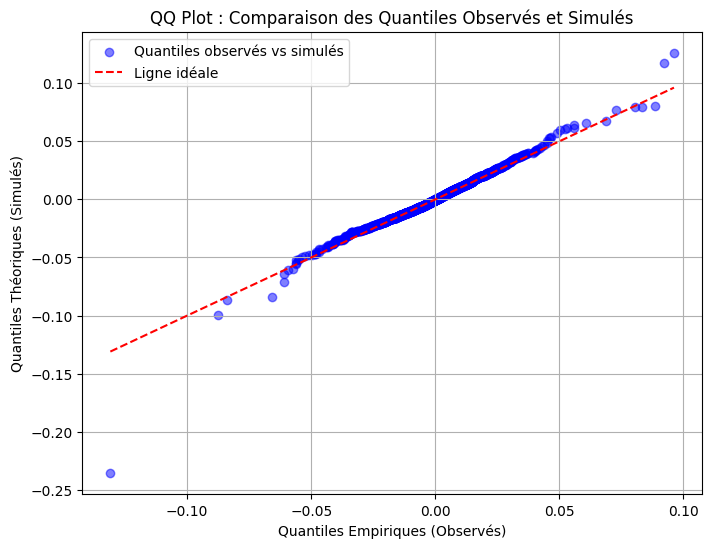

In [130]:
importlib.reload(functions)
T = len(train_data['Log Return'])
df_simulated = functions.skew_student_sim(mu_opt, sigma_opt, gamma_opt, nu_opt, T)
df_observed = train_data['Log Return']

fig = functions.qqplot(df_observed, df_simulated)
plt.show()

L'observation du QQ-plot, vient confirmer le constat fait précédemment avec les courbes de densités supperposées.

La loi skew student serait donc mieux adapté à nos données qu'une loi gaussienne.

Pour que ceci soit plus visuel, nous allons afficher côte à côte les QQ-plots pour ces deux lois.


#### Comparaison de la qualité de fit entre loi gaussienne et loi de skew Student par analyse graphique.



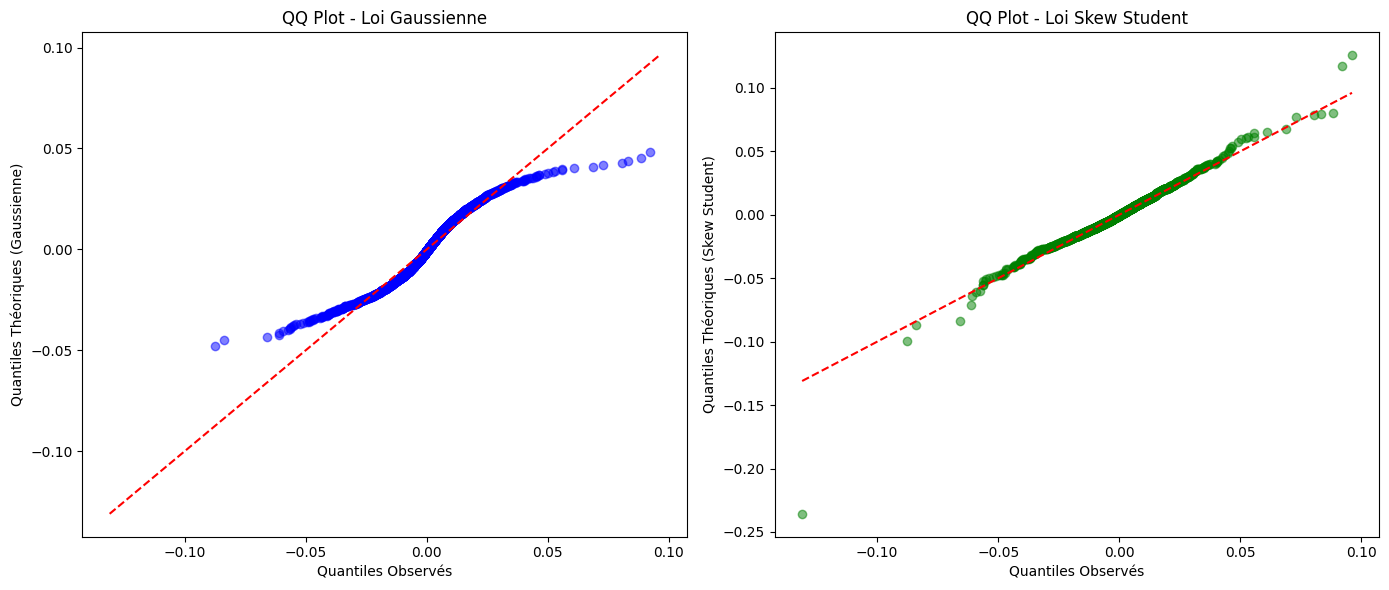

In [131]:
importlib.reload(functions)

# Paramètres des lois
mu_gauss, sigma_gauss = np.mean(train_data['Log Return']), np.std(train_data['Log Return'])
mu_skew, sigma_skew, gamma_skew, nu_skew = mu_opt, sigma_opt, gamma_opt, nu_opt

# Génération des QQ plots
functions.qqplot_gaussian_skew(train_data['Log Return'], mu_gauss, sigma_gauss, mu_skew, sigma_skew, gamma_skew, nu_skew)


La loi de Skew Student colle beaucoup mieux aux rendements extrêmes que la loi normale. Elle s’adapte mieux à la forme réelle de nos données, surtout dans les queues.



#### Calcul de la VaR Skew Student sur base d’apprentissage pour alpha = 99%.



In [132]:
importlib.reload(functions)
VaR_skew = functions.Var_param_student(train_data['Log Return'], confidence_level=0.99)

La VaR Skewed Student au niveau de confiance 99.0% est de : -0.0370


## Expected Shortfall

On s'intéresse à présent à un indicateur plus prudent et informatif que la VaR afin de compléter notre analyse : **l'Expected shortfall**. 

Il réprésente la perte moyenne attendue en cas de dépassement de la VaR, c’est-à-dire la moyenne des pertes dans les pires cas



#### Calcul de l’ES empirique associé à la mesure la VaR historique sur base d’apprentissage pour alpha = 99%. 


In [145]:
importlib.reload(functions)
print("La VaR historique (niveau 99%) est : ", round(var_99_hist, 4))
ES_hist =functions.ES_Hist(train_data['Log Return'])

La VaR historique (niveau 99%) est :  -0.0405
L'Expected Shortfall empirique historique au niveau de confiance 99.0% est : -0.053823


####  Calcul de l’ES empirique associé à la VaR gaussienne sur base d’apprentissage pour alpha = 99%. 

In [144]:
importlib.reload(functions)
print("La VaR gaussienne (niveau 99%) est : ", round(var_gauss, 4))
ES_emp_gauss = functions.ES_emp_gauss(train_data)

La VaR gaussienne (niveau 99%) est :  -0.0322
L'Expected Shortfall empirique gaussien au niveau de confiance 99.0% est : -0.044325


####  L'ES théorique basée sur la VaR gaussienne

In [143]:
importlib.reload(functions)
print("La VaR gaussienne (niveau 99%) est : ", round(var_gauss, 4))
ES_gauss = functions.ES_gauss(train_data, confidence_level=0.99)

La VaR gaussienne (niveau 99%) est :  -0.0322
ES théorique gaussien (niveau 99.0%) : -0.036884


#### Calcul de l'ES empirique basé sur la VaR skewed-student à 99%

In [138]:
importlib.reload(functions)
ES_emp_skew_student = functions.ES_emp_skew_student(train_data)

La VaR Skewed Student au niveau de confiance 99.0% est de : -0.0370
L'Expected Shortfall empirique skewed-student au niveau de confiance 99.0% est : -0.049202


####  Calcul de l'ES théorique associée à la VaR Skew student

In [147]:
importlib.reload(functions)
print("La VaR skew-student (niveau 99%) est : ", round(VaR_skew, 4))
ES_skew_student = functions.ES_skew_student(mu_opt, sigma_opt, gamma_opt, nu_opt, train_data, VaR_skew)

La VaR skew-student (niveau 99%) est :  -0.037
L'Expected Shortfall théorique skewed-student au niveau de confiance 99.0% est : -0.056004


## 	Protocole de backtesting

#### Proposition d'un protocole de backtesting 

Nous proposons ci dessous un protocole de backtesting adaptatif pour une VaR gaussienne



**Protocole de backtesting adaptatif :**  
Le protocole de backtesting proposé vise à vérifier la robustesse de l'estimation de la VaR par une approche paramétrique gaussienne en suivant trois étapes principales :  

1. **Calibration initiale :**  
   Le modèle est initialement calibré sur une période d’apprentissage fixe pour estimer la VaR gaussienne.  

2. **Backtesting ex-post quotidien :**  
   Le backtesting commence à partir du 30ᵉ jour afin de s'assurer que les hypothèses sous-jacentes des tests utilisés (notamment l'approximation des lois) sont satisfaites. À partir de ce moment-là, la VaR estimée est testée chaque jour sur une période glissante de taille prédéfinie (`window_size`).  
   Deux tests sont réalisés :  
   - **Unconditional Coverage Test (UC Test)** : Vérifie si la proportion d’exception observés est cohérente au seuil fixé, ici 1%.  
   - **Independence Test (IND Test)** : Vérifie si les excès sont indépendants dans le temps.  

3. **Mécanisme de recalibrage par fenêtre glissante :**  
   - **Recalibrage déclenché par exception :**  
     Si l'un des tests échoue (`UC Test` ou `IND Test`), un recalibrage est immédiatement déclenché.  
     La période d'entraînement est alors mise à jour par une fenêtre glissante : les observations les plus anciennes sont supprimées tandis que les nouvelles observations récentes sont ajoutées.  
     Par exemple, si une exception est détectée au 100ᵉ jour, les 100 premières observations de la période d'entraînement sont supprimées et remplacées par les 100 jours les plus récents des données de test. Cela permet d'actualiser les paramètres du modèle pour mieux refléter les conditions actuelles du marché.  

   - **Recalibrage en absence prolongée d’exception :**  
     Si aucune exception n'est détectée sur une longue période (`max_no_recalib = 252 jours`), un recalibrage est également effectué par une fenêtre glissante.  
     Cela garantit que le modèle reste pertinent même lorsqu’il semble bien fonctionner sur une longue période, évitant ainsi un ajustement excessivement conservateur.  

Ce protocole dynamique assure une adaptation continue du modèle, permettant d'estimer la VaR de manière fiable en s'adaptant aux nouvelles conditions de marché.  
 



#### Mise en place ce protocole sur les données de test

Pour ce faire, dans la partie dediée au code, on retrouvera : 

- la fonction : **perform_backtest*** qui fait conjointement le test d'unconditional coverage et le test d'independance

Ensuite la fonction 

- la fonction : **adaptive_backtesting** : Qui réalise le backtesting adaptatif

In [149]:
importlib.reload(functions)

result_var, result_date_recalib, jours_recalibrage = functions.adaptive_backtesting(train_data, test_data)

La VaR est recalibrée à la date 2023-03-16
après 165 jours.
------------------------------------------------------------
La valeur de la nouvelle VaR recalibrée est : -0.029898077522017466
------------------------------------------------------------


La VaR est recalibrée à la date 2023-07-07
après 78 jours.
------------------------------------------------------------
La valeur de la nouvelle VaR recalibrée est : -0.02971677178973731
------------------------------------------------------------


La VaR est recalibrée à la date 2024-04-09
après 192 jours.
------------------------------------------------------------
La valeur de la nouvelle VaR recalibrée est : -0.02862514975428418
------------------------------------------------------------




La théorie des valeurs extrêmes offre également d'importants insights pour le calcul de la Value at Risk. 

Nous allons présenter ci après les VaR obtenues via les méthodes dites :

    - Generalized Pareto Distribution (GPD)  qui est une approche par bloc Maxima et 
    -  Peak Over Threshold(POT)

##  VaR TVE : Approche Maxima par bloc

#### Détermination d'une taille de bloc s et construction d'un échantillon de maxima sur la base d’apprentissage.


On choisit s suffisamment grand pour satisfaire les conditions asymptotiques du théorème de  Fisher - Tippet
mais également suffisamment faible pour obtenir un échantillon de maxima de taille convenable

Dans notre cas, nous avons choisi comme taille de bloc 20

Compte tenu du fait que nous travaillons sur des données financières, cette taille represente donc des blocs mensuels.

####    Tracé de Gumbel plot pour juger de l’hypothèse ξ=0 (i.e. GEV vs EV).

Le Gumbel plot nous permettra de determiner si la distribution adaptée aux données est celle de Gumbel

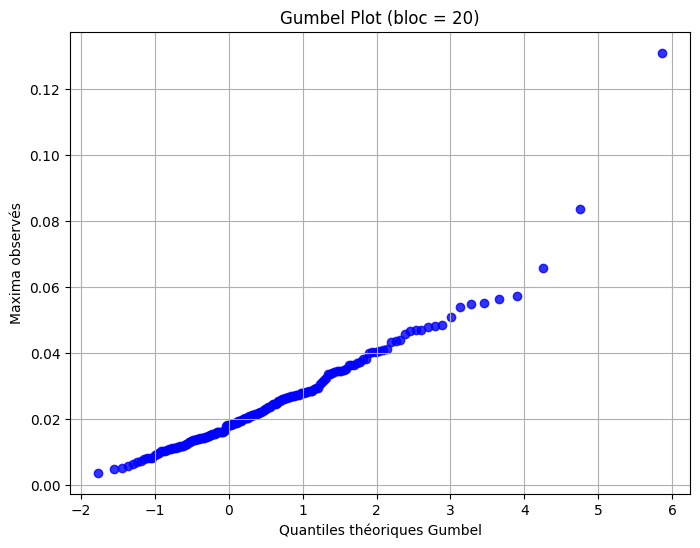

In [150]:
importlib.reload(functions)
functions.gumbel_plot(-train_data['Log Return'])

La courbe observée, présente une courbure mais, très peu prononcée. Pour être précautionaux, nous allons modéliser une GEV.
 
 #### 	Estimation des paramètres de loi GEV 


Nous avons opté pour des blocs de taille 20, qui correspondent dans notre cas à une période mensuelle.

In [152]:
importlib.reload(functions)
# Recuperons les paramètres de la GEV
block_max = functions.block_maxima(-train_data)
shape, loc, scale, neg_log_likelihood_value = functions.fit_gev(block_max)

# Affichons les résultats 
print(f"Shape (ξ): {shape}\n{'-'*50}")
print(f"Location (μ): {loc}\n{'-'*50}")
print(f"Scale (σ): {scale}\n{'-'*50}")
print(f"Negative Log-Likelihood: {neg_log_likelihood_value}\n{'-'*50}")

Shape (ξ): -0.1340739024682368
--------------------------------------------------
Location (μ): 0.017788373524147527
--------------------------------------------------
Scale (σ): 0.009618125539477461
--------------------------------------------------
Negative Log-Likelihood: 529.2834672681624
--------------------------------------------------


#### Faisons une validation ex-ante de notre ajustement

Nous allons pour ce faire, tester l'ajustement de nos données à la loi ajustée en utilisant un QQ plot, un test d'adéquation de kolmogorov smirnov, et un LR test, 

Pour voir si le fait d'avoir pris en compre cette courbure très prononcée apporte quelque chose à nos données approte quelque chose, nous allons fait un test de rapport de vraisemblance pour comparer la Gumble à la loi ajustée


QQ-Plot


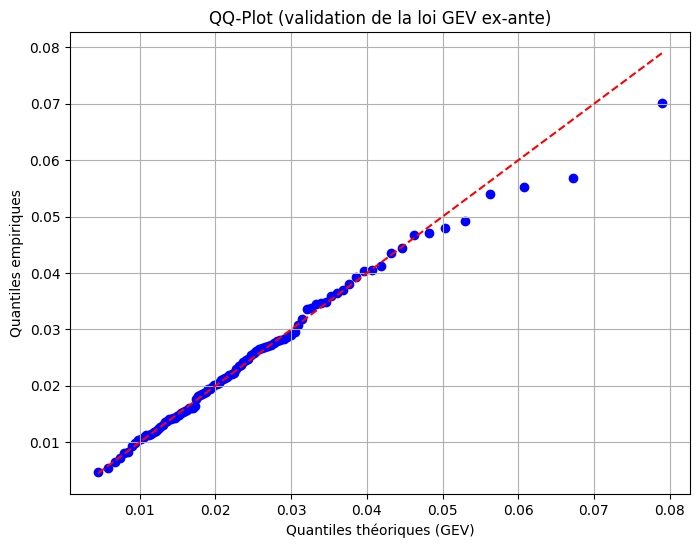

In [153]:
importlib.reload(functions)
functions.gev_plot(block_max , shape, loc, scale)

Le QQ-plot suggère que la loi GEV est globalement adaptée aux maxima extraits de nos blocs.
Les points soint assez bien alignés sur la premiere bissectrice, ce qui indique que la distribution théorique capture bien le comportement empirique, y compris dans les queues, malgré quelques écarts en très haute valeur.

Nous allons valider celà statistiquement avec un test de Kolmogorov-smirnov au seuil de 5%


In [154]:
importlib.reload(functions)
functions.ks_test_gev(block_max, shape, loc, scale, alpha=0.05)

--------------------------------------------------
Test de Kolmogorov-Smirnov pour la GEV

Statistique KS : 0.0404
p-value        : 0.9238

Résultat : on ne rejette pas H₀ au seuil 0.05.
La loi GEV est acceptable.

--------------------------------------------------



La courbure du Gumbel plot présenté précédemment etait très peu marquée et nous avons choisi de  modéliser une GEV pour être plus précautionneux. 

Nous voulons à présent savoir si le gain qu'on obtient en faisant ce choix est significatif. Nous allons donc pour ce faire effectuer un test de comparaison de vraisemblance **(LR test)**:

On compare les log vraisemblance de la GEV ajustée sur nos données à celle qu'aurait donné une Gumbel.


**Pour ce faire, on ajuste d'abord une Gumbel**

In [155]:
importlib.reload(functions)
loc_g, scale_g, neg_log_likelihood_value_g = functions.fit_gumbel(block_max)

**On réalise ensuite notre test de rapport de vraisemblance**

In [156]:
importlib.reload(functions)
functions.LR_test(neg_log_likelihood_value_g, neg_log_likelihood_value)

--------------------------------------------------
Test du rapport de vraisemblance : Gumbel (H₀) vs GEV (H₁)

Statistique LRT : -7.1161
p-value         : 1.0000

Résultat : pas d'amélioration significative par rapport au modèle Gumbel.
--------------------------------------------------


True

Statistiquement, il n'y a pas d'amelioration d'ajustement qui soit significatif en ajustant une GEV plutôt qu'une Gumbel.

L'effet d'une GEV est donc marginal.

Nous allons donc considerer la Gumbel pour le calcul de la VaR


#### Calcul de la VaR



In [158]:
importlib.reload(functions)
VaR_Gumbel = functions.calcul_VaR_Gumbel (loc_g, scale_g, block_size=20)

La VaR Gumbel est : -0.03492178637571426
----------------------------------------


## VaR TVE : Approche Peak over threshold



####  Ecrivons une fonction permettant d’obtenir le mean excess plot et determinons le seuil u par une analyse graphique

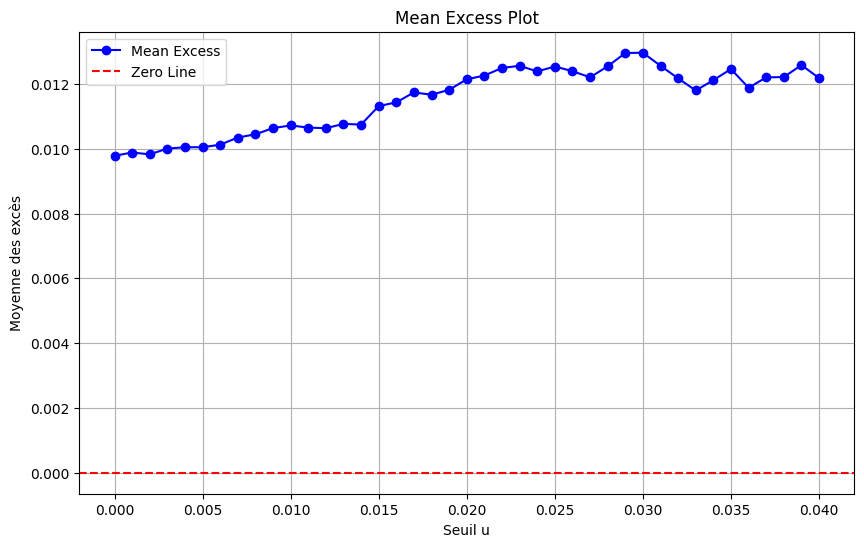

In [160]:
importlib.reload(functions)
functions.mean_excess_plot(-train_data, u_min=0, u_max=None, step=0.001)

En observant le mean excess plot, on opte pour u = 0.028. 
Le comportement des mean excess au delà de u, sont plus ou moins linéaires. Mais il est important que u soit suffisamment élevé pour respecter les conditions asymptotiques. 

Nous optons donc pour cette valeur et voyons les caractéristiques de la loi ajustée

#### Estimation  des paramètres de loi GPD



In [161]:
importlib.reload(functions)
shape, loc, scale =functions.fit_gpd(-train_data['Log Return'].to_numpy(), u = 0.028)
print("-" * 50)
print("Paramètres calibrés de la loi GPD\n")
print(f"Shape (ξ)  : {shape:.4f}")
print(f"Loc        : {loc:.4f}")
print(f"Scale (σ)  : {scale:.4f}")
print("-" * 50)


--------------------------------------------------
Paramètres calibrés de la loi GPD

Shape (ξ)  : 0.0782
Loc        : 0.0000
Scale (σ)  : 0.0115
--------------------------------------------------


####  Faire une validation ex-ante (analyse graphiques, QQ-plot, etc.)

Nous utilisons pour ce faire un QQ-plot, un PP-plot et un test de kolmogorov smirnov



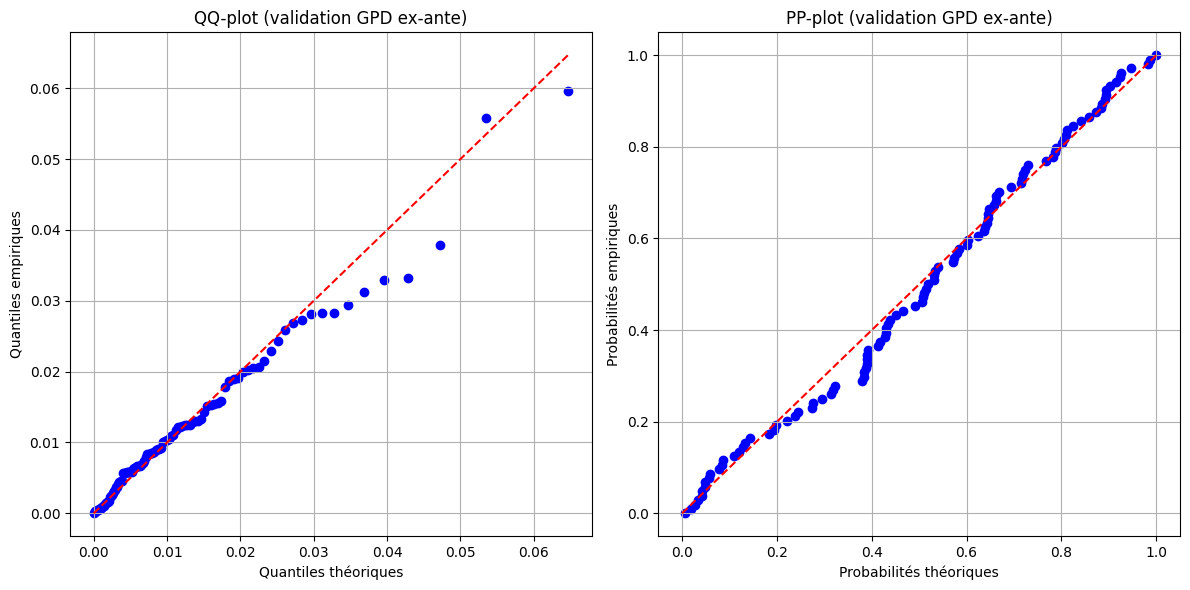

In [162]:
importlib.reload(functions)
u = 0.028
gpd_validation = functions.gpd_validation(-train_data['Log Return'].to_numpy(), u, shape, scale)

Le QQ plot et le PP plot affichent un plus ou moins bien ajustement de la loi GPD aux données. Bien qu'elle sous estime quelque peu les valeurs extrêmes.

Cet assez bon ajustement est corroborée par un test statistique de Kolmogorov smirnov qui soutient que la GPD arrive à bien modéliser les excès.

Test de Kolmogorov_smirnov

In [163]:
importlib.reload(functions)
functions.gpd_ks_test(-train_data['Log Return'], u, shape, scale, alpha=0.05)

--------------------------------------------------
Test de Kolmogorov-Smirnov pour la loi GPD

Statistique KS : 0.0947
p-value        : 0.2852

Résultat : H₀ non rejetée au seuil 0.05.
Conclusion : la loi GPD est acceptable pour les excès.

--------------------------------------------------


####  Calculer de la VaR TVE par PoT sur base d’apprentissage pour alpha = 99%.

In [164]:
importlib.reload(functions)
var_tve_pot_result = functions.var_tve_pot(-train_data['Log Return'].to_numpy(), u, shape, scale)
print("-" * 50)
print("la VaR TVE par PoT à un niveau de confiance 99 % est :\n")
print(f"VaR TVE  : {var_tve_pot_result :.4f}")
print("-" * 50)

--------------------------------------------------
la VaR TVE par PoT à un niveau de confiance 99 % est :

VaR TVE  : -0.0412
--------------------------------------------------



Le choix du seuil u, étant très subjectif et  généralement pas aisé, nous proposons ci après un protocole qui permet une selection automatique d'un bon seuil pour la méthode POT.

#### 	Proposition  d'un protocole permettant de calibrer u de manière automatique, et le mettre en œuvre.



Afin de déterminer le seuil optimal, il ne doit pas être trop bas pour éviter d’inclure des données trop fréquentes, ni trop élevé afin de conserver suffisamment d'observations pour une modélisation fiable. Pour cette raison, un seuil minimal est fixé au quantile d'ordre 90% et un seuil maximal au quantile 99%. Avec un pas ajustable de 0.0001, nous explorons la plage de valeurs comprises entre u_min et u_max. Pour chaque seuil, nous estimons les paramètres de la loi GPD. Nous calculons ensuite les écarts absolus entre les estimations successives des paramètres scale et shape. Ces écarts sont additionnés pour chaque seuil afin de mesurer la stabilité des estimations. Le seuil optimal correspond à celui où la somme de ces écarts est minimale, indiquant une stabilité maximale des paramètres estimés.

##### Implémentation du protocole


In [166]:
importlib.reload(functions)
u = functions.calibrate_u(-train_data['Log Return'].to_numpy(), alpha=0.99, step=0.0001) 

In [167]:
print('-'*40)
print("Le paramètre u optimal dans le cadre de notre exercice présent est", u)
print('-'*40)

----------------------------------------
Le paramètre u optimal dans le cadre de notre exercice présent est 0.02734745956723591
----------------------------------------


## 	VaR  GARCH 


#### Etude de  l’applicabilité d’un modèle AR[1]-GARCH[1,1] à la série des log-rendements historiques sur base d’apprentissage.

On procédera de manière séquentielle : plausibilité d’un AR[1], étude de l’homoscedasticité des résidus de l’AR[1]


##### Spécification d'un AR(1) sur les rendements et analyse des résidus

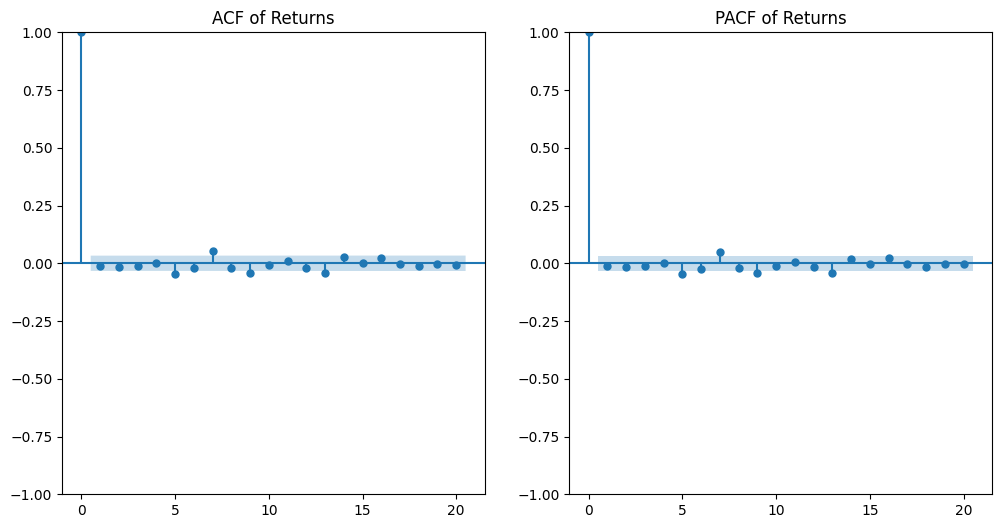

ADF Statistic: -60.09005708954505
p-value: 0.0
Critical Values: {'1%': -3.4322085838690244, '5%': -2.862361217190852, '10%': -2.567207147908185}
                               SARIMAX Results                                
Dep. Variable:             Log Return   No. Observations:                 3522
Model:                 ARIMA(1, 0, 0)   Log Likelihood               10061.836
Date:                Sat, 19 Apr 2025   AIC                         -20117.673
Time:                        14:53:50   BIC                         -20099.173
Sample:                             0   HQIC                        -20111.072
                               - 3522                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.711      0.477      -0.00

In [168]:
### Spécification d'un AR(1) et analyse des résidus


# Analyse de  l'ACF et du PACF des rendements
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plot_acf(train_data['Log Return'], lags=20, ax=plt.gca())
plt.title('ACF of Returns')

plt.subplot(1, 2, 2)
plot_pacf(train_data['Log Return'], lags=20, ax=plt.gca())
plt.title('PACF of Returns')
plt.show()

# Test de stationnarité (ADF test)
adf_result = adfuller(train_data['Log Return'])
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print(f"Critical Values: {adf_result[4]}")

# On ajuste un modèle AR(1) sur nos rendements
ar_model = ARIMA(train_data['Log Return'], order=(1, 0, 0)).fit()
print(ar_model.summary())



Les coefficients const et ar.L1 ne sont pas significatifs, ce qui indique qu’un modèle AR(1) ne capture pas bien la dynamique de la série. 

En s'intéressant notamment aux residus de cette modélisation AR(1) (présentés ci-dessous), il en ressort qu'en effet, ce modèle n'est pas adapté à la dynamique des rendements

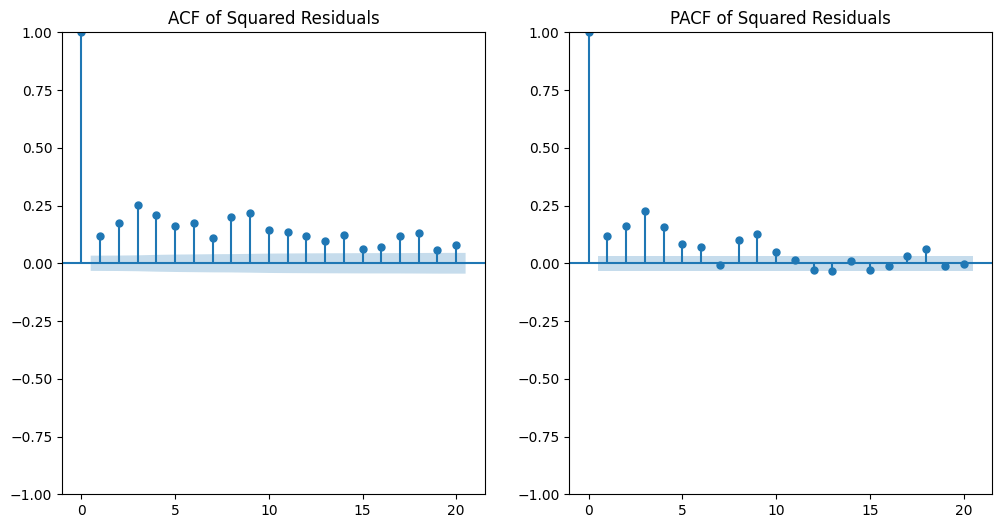

In [169]:
residuals = ar_model.resid

# Plot ACF and PACF of squared residuals
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plot_acf(residuals**2, lags=20, ax=plt.gca())
plt.title('ACF of Squared Residuals')

plt.subplot(1, 2, 2)
plot_pacf(residuals**2, lags=20, ax=plt.gca())
plt.title('PACF of Squared Residuals')
plt.show()

L'ACF ci dessus suggère une présence subtantielle d'autocorellation dans les residus du modèle AR(1). Cette observation est validée statistiquement par un test statistique : le test de **Ljung box**. 

In [170]:
ljung_box_pvalues_squared = acorr_ljungbox(residuals, lags=[10], return_df=True)
print("Résultats du test de Ljung-Box sur les résidus  :")
print(ljung_box_pvalues_squared)

Résultats du test de Ljung-Box sur les résidus  :
      lb_stat  lb_pvalue
10  28.151382   0.001707


**Conclusion 1** : 

Le modèle AR(1) n'est clairement pas celui adapté pour modéliser la dynamique de nos log-rendements. Nous allons explorer d'autres approches.



Nous allons faire un ajustement GARCH[1,1] sur les residus du AR(1) précédent et allons analyser le comportement des residus obtenus

##### Ajustement d'un GARCH(1,1) sur les résidus de l'AR(1) 

 

Iteration:      1,   Func. Count:      6,   Neg. LLF: 23102908148.648552
Iteration:      2,   Func. Count:     20,   Neg. LLF: 11712205168869.465
Iteration:      3,   Func. Count:     34,   Neg. LLF: 388203470624.01
Iteration:      4,   Func. Count:     49,   Neg. LLF: 1614270927.4543347
Iteration:      5,   Func. Count:     63,   Neg. LLF: 1872961297.6593926
Optimization terminated successfully    (Exit mode 0)
            Current function value: -10642.68698300367
            Iterations: 5
            Function evaluations: 73
            Gradient evaluations: 5
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                10642.7
Distribution:                  Normal   AIC:                          -21277.4
Method:            Maximum Likeliho

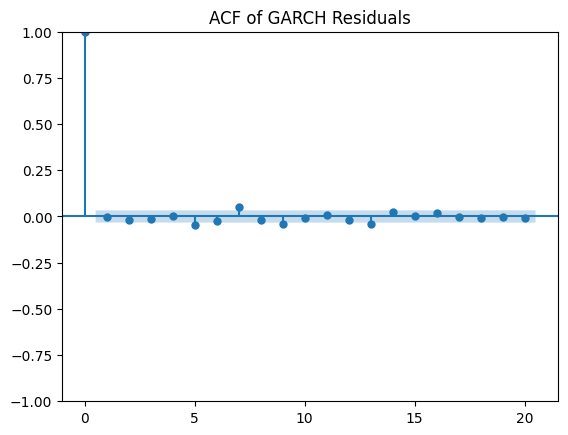

In [171]:

garch_model = arch_model(residuals, vol='Garch', p=1, q=1)
garch_fit = garch_model.fit()
print(garch_fit.summary())

# Plot ACF of GARCH residuals
garch_residuals = garch_fit.resid
plot_acf(garch_residuals, lags=20)
plt.title('ACF of GARCH Residuals')
plt.show()

Les coefficients du GARCH(1,1) sont tous significatifs, de plus , et, en observant l'ACF, on n'observe pas d'autocorellation dans les residus du modèle mis en place.

Ceci, nous amène donc à postuler pour un modèle de type AR(1)- GARCH(1,1) pour modéliser la dynamique des log rendements


#### Estimation des paramètres du modèle AR[1]-GARCH[1,1] sur base d’apprentissage 




In [172]:
combined_model = arch_model(train_data['Log Return'], mean='AR', lags=1, vol='Garch', p=1, q=1)
combined_fit = combined_model.fit()
print(combined_fit.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 24436065804.187126
Iteration:      2,   Func. Count:     22,   Neg. LLF: 419359748.06273526
Iteration:      3,   Func. Count:     35,   Neg. LLF: -10641.440802076222
Optimization terminated successfully    (Exit mode 0)
            Current function value: -10641.440807547062
            Iterations: 7
            Function evaluations: 35
            Gradient evaluations: 3
                           AR - GARCH Model Results                           
Dep. Variable:             Log Return   R-squared:                      -0.001
Mean Model:                        AR   Adj. R-squared:                 -0.001
Vol Model:                      GARCH   Log-Likelihood:                10641.4
Distribution:                  Normal   AIC:                          -21272.9
Method:            Maximum Likelihood   BIC:                          -21242.0
                                        No. Observations:                 3521
Date:             

#### Vérifions que les résidus de l’AR[1]-GARCH[1,1] sont bien représentatifs d’un bruit blanc i.i.d.



- On verifie si les résidus sont décorrelés

In [173]:
# Récupérons les résidus standardisés du modèle AR(1)-GARCH(1,1)

residuals = combined_fit.std_resid  
residuals = residuals.dropna()
# Test d'autocorrélation avec Ljung-Box
ljung_box_pvalues = acorr_ljungbox(residuals, lags=[10], return_df=True)
ljung_box_pvalues_squared = acorr_ljungbox(residuals**2, lags=[10], return_df=True)
print("Résultats du test de Ljung-Box sur les résidus :")
print(ljung_box_pvalues)

Résultats du test de Ljung-Box sur les résidus :
     lb_stat  lb_pvalue
10  5.031271   0.889079


La p-value du test de Ljung-box est superieure à 0.05, ce qui signifie que au seuil de 5%, on peut rejetter l'hypothèse d'autocorrelation des residus du modèle postulé.



- On s'assure aussi que la volatilité conditionnelle est bien modélisée par le GARCH.

Pour ce faire, on va tester l'auto-correlation des residus studentisés élévés au carré



In [174]:
ljung_box_pvalues_squared = acorr_ljungbox(residuals**2, lags=[10], return_df=True)
print("Résultats du test de Ljung-Box sur les résidus au carré :")
print(ljung_box_pvalues_squared)

Résultats du test de Ljung-Box sur les résidus au carré :
     lb_stat  lb_pvalue
10  11.54687   0.316526


La volatilité conditionnelle est bien donc modélisée par le GARCH



- On s'assure que ces residus sont identiquement distribués

Pour ce faire, on essaie de modéliser la loi qui les régit : On effectue des test de normalité à savoir le test de forme de Jacques Bera et le test de Shapiro-wilk


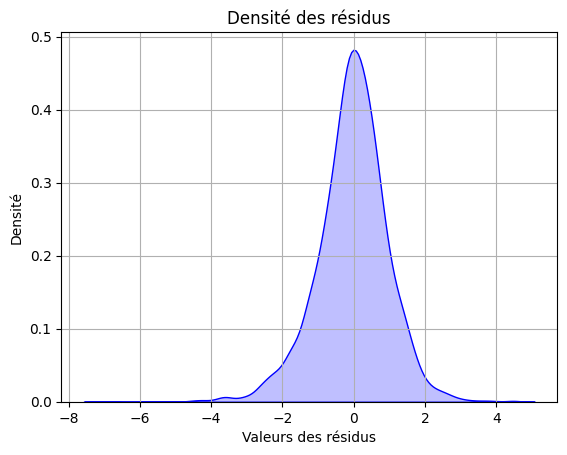

In [175]:
# Tracer la densité (KDE) des résidus
sns.kdeplot(residuals, shade=True, color='blue')
plt.title("Densité des résidus")
plt.xlabel("Valeurs des résidus")
plt.ylabel("Densité")
plt.grid(True)
plt.show()

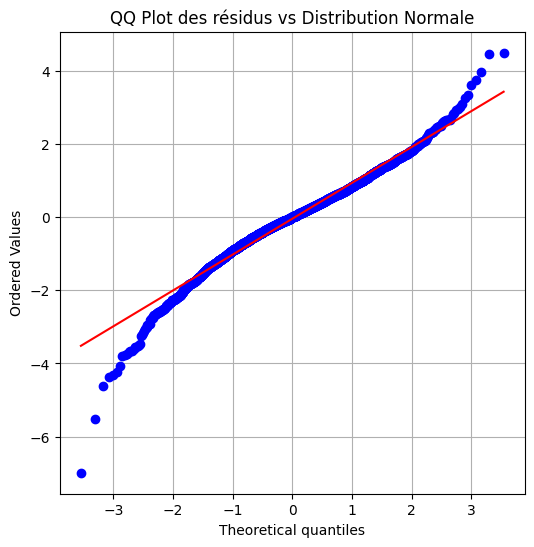

In [176]:
# Tracer le QQ plot
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot des résidus vs Distribution Normale")
plt.grid(True)
plt.show()

In [177]:

#Test de normalité avec Jarque-Bera
jb_stat, jb_pvalue = jarque_bera(residuals)

print("\nRésultat du test de Jarque-Bera :")
print(f"JB-stat = {jb_stat:.3f}, p-value = {jb_pvalue:.3f}")


Résultat du test de Jarque-Bera :
JB-stat = 861.878, p-value = 0.000


In [178]:
# Test de Shapiro-Wilk
shapiro_stat, shapiro_pvalue = shapiro(residuals)

print("\nRésultat du test de Shapiro-Wilk :")
print(f"Statistique W = {shapiro_stat:.3f}, p-value = {shapiro_pvalue:.3f}")


Résultat du test de Shapiro-Wilk :
Statistique W = 0.978, p-value = 0.000



**Analyse des resultats relatifs à la distribution des residus**


Bien que les outils graphiques suggèrent une distribution normale des residus, les tests statistiques effectuées ont condduit au rejet de cette hypothèse. Ceci suggère que, a priori, les residus ne sont pas identiquement distribués. 

Malgré cela, nous conservons le modèle AR(1)-GARCH(1,1) en raison de sa simplicité d'interprétation et de sa pertinence pédagogique.  

Ce modèle constitue un bon point de départ pour la modélisation de la VaR, avec une structure claire où :  
- **𝜔 (omega)** représente la volatilité  de long terme,  
- **𝛼 (alpha)** mesure la réaction immédiate aux chocs récents,  
- **𝛽 (beta)** reflète la persistance de la volatilité à travers le temps.  

  



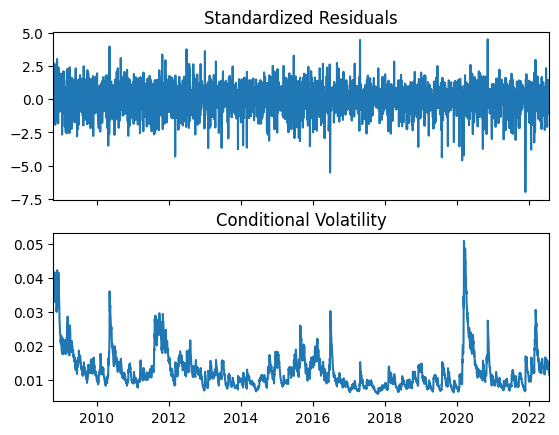

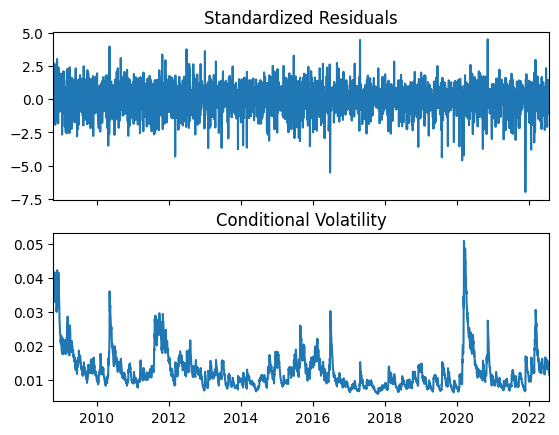

In [179]:
### On regarde la forme du combined plot pour notre modèle.
combined_fit.plot()

#### 	Reproduisons sur l’ensemble de la période (apprentissage + test)  la dynamique historique de μ_t et σ_t selon la dynamique et les valeurs initiales fournies dans le support de cours.



In [196]:
mu, phi, omega, a, b = combined_fit.params
data = pd.concat([train_data, test_data])
std_residuals = combined_fit.std_resid 
alpha = 0.99
q = std_residuals.quantile(1-alpha) 

data["mu"] = mu + phi*data['Log Return'].shift()
data["mu"][0] = mu

data["vol"] = np.sqrt(omega/(1-a-b))

for t in range(1, len(data)):
    data["vol"][t] = np.sqrt(omega + 
                             a*(data['Log Return'][t-1] - data["mu"][t-1])**2 
                            + b*data["vol"][t-1]**2
                               )
data["VaR"] = data["mu"] + data["vol"]*q
data.head(2)  




,Close,Log Return,VaR_exceedance,Exception,mu,vol,VaR
Date,,,,,,,
2008-10-16,3181.000000,-0.060997,True,NaN,0.000558,0.013865,-0.036497
2008-10-17,3329.919922,0.045753,False,NaN,0.001176,0.023493,-0.061611


####  Pour les méthodes historique et GPD de calcul de VaR, nous allons

-   Estimer la VaR sur les résidus
-   	Calculer la VaR dynamique et les exceptions associées sur la base de test



##### Cas de la VaR historique


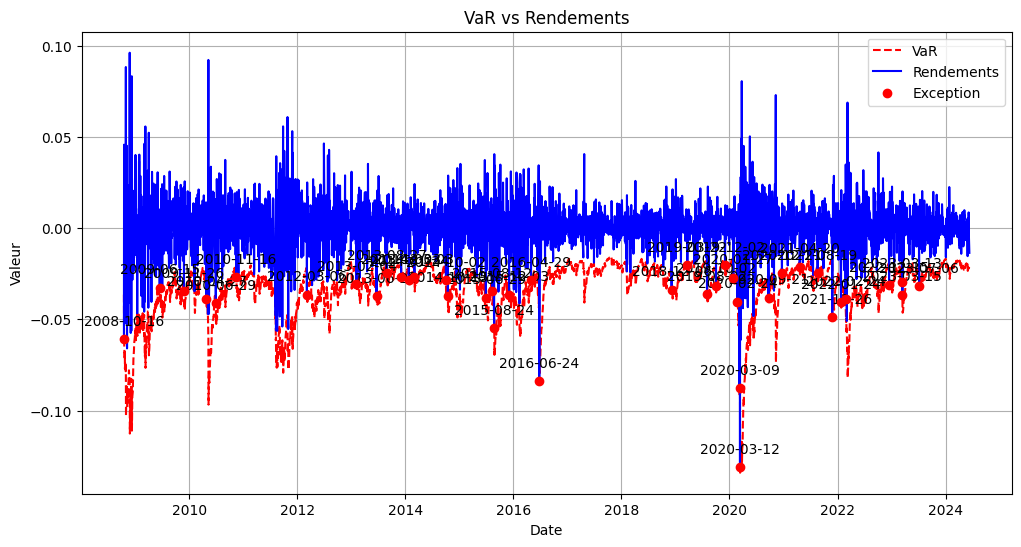

In [197]:
plt.figure(figsize=(12, 6))

# Tracer la VaR et les rendements
plt.plot(data.index, data["VaR"], label="VaR", color="red", linestyle="--")
plt.plot(data.index, data['Log Return'], label="Rendements", color="blue")

# Identifier les points où la VaR excède les rendements
exceedance_points = data[data["VaR"] > data['Log Return']]

# Marquer ces points avec des points rouges
plt.scatter(exceedance_points.index, exceedance_points['Log Return'], color="red", label="Exception", zorder=5)

# Annoter les points critiques
for date, return_value in exceedance_points['Log Return'].items():
    plt.annotate(date.strftime('%Y-%m-%d'), (date, return_value), textcoords="offset points", xytext=(0, 10), ha='center')

# Ajouter des labels et une légende
plt.title("VaR vs Rendements")
plt.xlabel("Date")
plt.ylabel("Valeur")
plt.legend()
plt.grid()

# Afficher le graphique
plt.show()


##### Cas de la VaR GPD

In [198]:
# On ajuste un AR(1)_GARCH(1,1)
combined_model = arch_model(train_data['Log Return'], mean='AR', lags=1, vol='Garch', p=1, q=1)
combined_fit = combined_model.fit()

# On recupère les residus
std_residuals = combined_fit.std_resid.dropna().to_numpy()
std_residuals = -std_residuals

Iteration:      1,   Func. Count:      7,   Neg. LLF: 24436065804.187126
Iteration:      2,   Func. Count:     22,   Neg. LLF: 419359748.06273526
Iteration:      3,   Func. Count:     35,   Neg. LLF: -10641.440802076222
Optimization terminated successfully    (Exit mode 0)
            Current function value: -10641.440807547062
            Iterations: 7
            Function evaluations: 35
            Gradient evaluations: 3


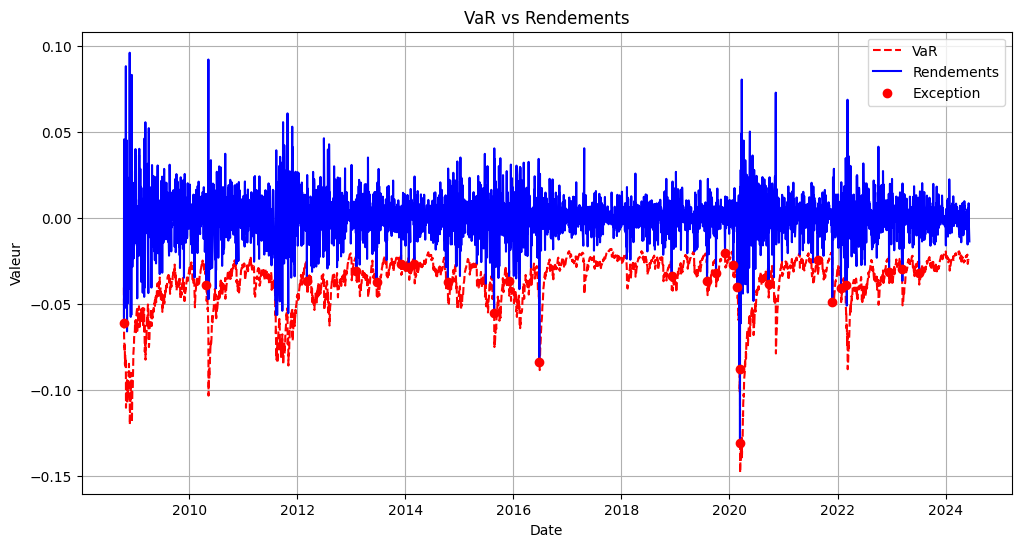

In [199]:
importlib.reload(functions)
functions.compute_and_plot_var_GPD(std_residuals, alpha, combined_fit, train_data, test_data)

## Conclusion



L'estimation de la Value at Risk (VaR) est une tâche essentielle pour nous qui sommes appelés à être des modélisateur, car elle constitue un indicateur clé qui oriente la prise de decision, des banques, des prestataires de services d'investissement, et même des  sociétés de gestion de portefeuilles.

Dans la littérature, plusieurs méthodes permettent d'estimer la Value at Risk. Dans le cadre de ce cours, et plus particulièrement de ce projet, nous avons exploré diverses approches, allant de la méthode gaussienne classique à des modèles plus sophistiqués tels que le modèle AR(1)-GARCH(1,1).

Chacune de ces méthodes a montré ses limites, tant au niveau du calcul du nombre d'exceptions que de l'application du protocole de backtesting.

En se concentrant plus spécifiquement sur les modèles de type série temporelle, les tests statistiques réalisés dans le cadre de la modélisation AR(1) — notamment sur les résidus, la distribution et la volatilité — ont mis en évidence deux points clés : les résidus ne suivent pas la même loi de distribution, et la volatilité n’est pas constante.

Ces observations nous ont naturellement conduit au passage à un modèle conditionnel de type AR(1)-GARCH(1,1), plus adapté pour modéliser les variations de la volatilité dans le temps.

En combinant ce modèle avec une loi de queue plus souple (la GPD dans notre cas), nous avons pu affiner l’estimation de la VaR, notamment dans les zones extrêmes.

La version dynamique de la VaR, fondée sur ce modèle, s’est révélée la plus pertinente : elle s’ajuste mieux aux fluctuations des données et permet d’identifier plus efficacement les périodes de stress.

Cela montre que, bien que ces modèles soient plus sophistiqués et donc plus complexes à implémenter, leur utilisation permet d’obtenir un gain significatif en termes de précision.


Par ailleurs, ce projet nous a permis d'approfondir notre compréhension des défis associés à l'estimation de la VaR, ainsi que des difficultés rencontrées avec les différentes approches. Cela inclut, par exemple, la détermination de la taille des blocs pour l'approche des blocs maxima, ou encore le choix du seuil optimal dans le cadre de l'approche POT. Nous avons été amenés  à pousser la  réflexion de manière plus approfondie afin de concevoir nous même des mécanismes permettant de sélectionner automatiquement certains paramètres, optimisant ainsi le processus d'estimation.

